# SaaS / Subscription Churn Prediction & Analysis

## Exploratory Data Analysis

### Objective

Explore the raw customer subscription dataset to understand:

- Dataset structure and data quality
- Customer and subscription characteristics
- Churn distribution
- Numerical feature distributions
- Categorical feature distributions
- Potential relationships between customer attributes and churn

### Business Objective

Identify customers at risk of churn and quantify the recurring revenue potentially at risk so that the business can prioritize retention efforts.

### Analysis Principle

This analysis will prioritize business relevance, interpretability, and clear reasoning over unnecessary feature complexity.

## EDA Roadmap

1. Load the raw dataset
2. Inspect dataset structure
3. Audit data quality
4. Investigate potential hidden/malformed missing values
5. Analyze churn class balance
6. Analyze numerical variables
7. Analyze categorical variables
8. Compare customer characteristics by churn status
9. Identify initial business patterns
10. Document observations and implications

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Load Raw Dataset

The raw dataset is loaded directly from `data/raw/` and is not modified during the initial inspection stage.

In [54]:
file_path = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Dataset Structure

The first structural checks establish the dataset size, column names, data types, and overall composition before any cleaning or transformation is performed.

In [55]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 7,043
Columns: 21


In [56]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [58]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,"7,043.00",NaN,NaN,NaN,0.16,0.37,0.00,0.00,0.00,0.00,1.00
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,"7,043.00",NaN,NaN,NaN,32.37,24.56,0.00,9.00,29.00,55.00,72.00
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Raw Data Quality Audit

Before performing transformations or feature engineering, the raw dataset is
audited for duplicates, null values, blank values, identifier uniqueness,
data types, and categorical-value consistency.

The purpose of this stage is to understand the quality of the source data
before making any cleaning decisions.

### 3.1 Duplicate Records

Duplicate records can distort customer-level churn rates and revenue
calculations, so duplicate rows are checked before analysis.

In [59]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 0


### 3.2 Missing Values

A standard null-value audit is performed using Pandas `isna()`.

This is only the first stage of the missing-value investigation because
blank strings or whitespace-only values may not be recognized as nulls.

In [60]:
null_counts = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

null_counts

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

In [61]:
print(f"Total null cells: {df.isna().sum().sum():,}")

Total null cells: 0


### 3.3 Blank and Whitespace-Only Values

The raw CSV may contain blank or whitespace-only strings that are not
identified by `isna()`.

Each object/string column is therefore checked for values that are empty
after removing surrounding whitespace.

In [62]:
object_columns = df.select_dtypes(include="object").columns

blank_counts = {}

for col in object_columns:
    blank_counts[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

blank_counts = (
    pd.Series(blank_counts)
    .sort_values(ascending=False)
)

blank_counts

TotalCharges        11
customerID           0
gender               0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
DeviceProtection     0
OnlineBackup         0
OnlineSecurity       0
InternetService      0
MultipleLines        0
PhoneService         0
Dependents           0
Partner              0
Churn                0
dtype: int64

In [63]:
blank_counts[blank_counts > 0]

TotalCharges    11
dtype: int64

### 3.4 TotalCharges Data-Type Investigation

`TotalCharges` represents cumulative charges but was loaded as an object
column rather than a numeric column.

The column is investigated for non-numeric or blank values before deciding
how it should be cleaned and converted.

In [64]:
total_charges_as_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

conversion_failures = (
    df["TotalCharges"].notna()
    & total_charges_as_numeric.isna()
)

print(f"Values that fail numeric conversion: {conversion_failures.sum():,}")

Values that fail numeric conversion: 11


In [65]:
df.loc[conversion_failures, ["customerID", "tenure", "TotalCharges", "Churn"]]

,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,,No
753,3115-CZMZD,0,,No
936,5709-LVOEQ,0,,No
1082,4367-NUYAO,0,,No
1340,1371-DWPAZ,0,,No
3331,7644-OMVMY,0,,No
3826,3213-VVOLG,0,,No
4380,2520-SGTTA,0,,No
5218,2923-ARZLG,0,,No
6670,4075-WKNIU,0,,No


In [66]:
df.loc[
    conversion_failures,
    ["tenure", "Churn"]
].sort_values("tenure")

,tenure,Churn
488,0,No
753,0,No
936,0,No
1082,0,No
1340,0,No
3331,0,No
3826,0,No
4380,0,No
5218,0,No
6670,0,No


### 3.5 Customer Identifier Uniqueness

Because the analysis is performed at customer level, each `customerID`
should represent one customer record.

Customer identifier uniqueness is therefore checked before downstream
aggregation and modeling.

In [67]:
unique_customers = df["customerID"].nunique()
total_rows = len(df)

print(f"Total rows: {total_rows:,}")
print(f"Unique customer IDs: {unique_customers:,}")
print(f"Duplicate customer IDs: {total_rows - unique_customers:,}")

Total rows: 7,043
Unique customer IDs: 7,043
Duplicate customer IDs: 0


### 3.6 Categorical Value Consistency

Categorical columns are reviewed for unexpected spellings, inconsistent
capitalization, or unusual categories that could affect segmentation.

In [68]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- customerID ---
customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup -

### 3.7 Raw Data Quality Summary

The initial audit produced the following observations:

- The dataset contains 7,043 customer records and 21 columns.
- No duplicate rows were identified.
- No Pandas null values were detected through `isna()`.
- A separate blank-value audit identified 11 blank values in `TotalCharges`.
- All 11 `TotalCharges` records that failed numeric conversion correspond to customers with `tenure = 0`.
- All 11 of these customers are currently classified as non-churned (`Churn = No`).
- `customerID` is unique across all 7,043 records.
- The categorical variables showed consistent category labels with no obvious spelling or capitalization inconsistencies.
- `TotalCharges` requires explicit cleaning and numeric conversion before it can be reliably used in downstream analysis.

No values are modified or removed during this raw-data audit. Cleaning decisions are deferred to the dedicated Pandas cleaning and feature-engineering stage.

## 4. Churn Baseline

The churn baseline establishes the size of the customer-retention problem before investigating the characteristics associated with churn.

This baseline will be used as a reference point for subsequent segmentation, predictive modeling, and revenue-at-risk analysis.

### 4.1 Customer Churn Counts

In [69]:
customer_counts = df["Churn"].value_counts()

total_customers = len(df)
churned_customers = customer_counts.get("Yes", 0)
retained_customers = customer_counts.get("No", 0)

print(f"Total customers: {total_customers:,}")
print(f"Churned customers: {churned_customers:,}")
print(f"Retained customers: {retained_customers:,}")

Total customers: 7,043
Churned customers: 1,869
Retained customers: 5,174


### 4.2 Churn and Retention Rates

In [70]:
churn_rate = churned_customers / total_customers
retention_rate = retained_customers / total_customers

print(f"Churn rate: {churn_rate:.2%}")
print(f"Retention rate: {retention_rate:.2%}")

Churn rate: 26.54%
Retention rate: 73.46%


In [71]:
churn_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Churn Rate",
        "Retention Rate"
    ],
    "Value": [
        total_customers,
        churned_customers,
        retained_customers,
        churn_rate,
        retention_rate
    ]
})

churn_summary

,Metric,Value
0,Total Customers,"7,043.00"
1,Churned Customers,"1,869.00"
2,Retained Customers,"5,174.00"
3,Churn Rate,0.27
4,Retention Rate,0.73


### 4.3 Churn Distribution

The churn distribution provides a visual view of the proportion of customers who have churned versus those who remain active.

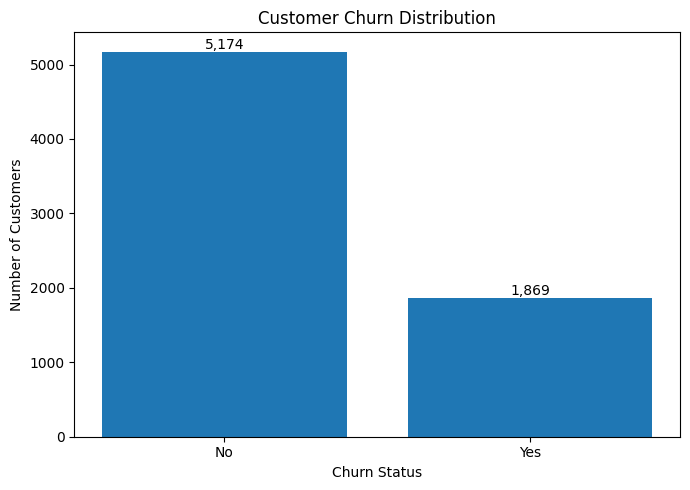

In [72]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

for i, value in enumerate(churn_counts.values):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [73]:
churn_percentages = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
)

churn_percentages

Churn
No    73.46
Yes   26.54
Name: proportion, dtype: float64

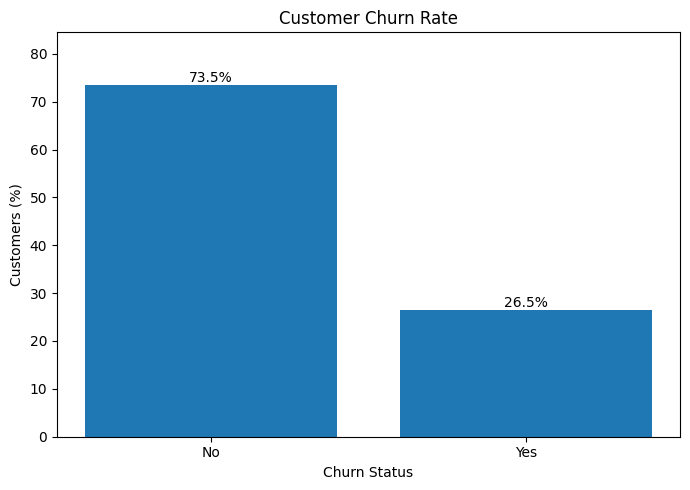

In [74]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    churn_percentages.index,
    churn_percentages.values
)

plt.title("Customer Churn Rate")
plt.xlabel("Churn Status")
plt.ylabel("Customers (%)")

for bar, value in zip(bars, churn_percentages.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(churn_percentages.values) * 1.15)
plt.tight_layout()
plt.show()

### 4.4 Initial Business Interpretation

The dataset contains 7,043 customers, of whom 1,869 have churned and 5,174 have remained active.

The overall churn rate is 26.54%, meaning that more than one quarter of the observed customer base has churned.

This establishes a meaningful retention problem and provides the baseline against which customer segments and future churn-risk predictions can be evaluated.

The baseline alone does not explain why customers churn or which customers should be targeted for retention. Further analysis is required to identify the customer and subscription characteristics associated with higher churn.

## 5. Numerical Feature Distributions

Numerical variables are examined to understand their distributions and identify potential differences in customer characteristics.

The primary numerical variables are:

- `tenure`: customer relationship duration in months
- `MonthlyCharges`: recurring monthly customer charges
- `TotalCharges`: cumulative customer charges

`TotalCharges` requires additional cleaning because the raw dataset contains blank values and is currently loaded as an object column. Therefore, it will not be used as a cleaned numerical variable until the dedicated data-cleaning stage.

### 5.1 Summary Statistics

In [75]:
numeric_columns = ["tenure", "MonthlyCharges"]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,"7,043.00",32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,"7,043.00",64.76,30.09,18.25,35.50,70.35,89.85,118.75


### 5.2 Customer Tenure Distribution

Customer tenure represents the number of months a customer has remained with the company.

Understanding tenure is important because customer relationship duration may help explain differences in churn behavior.

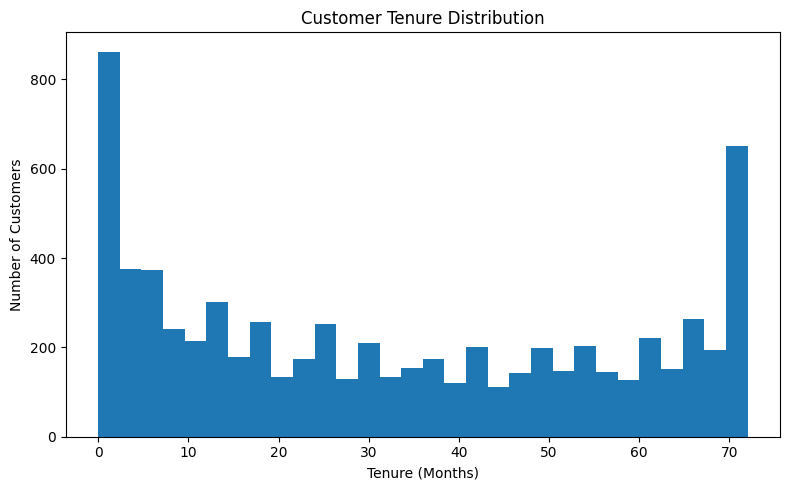

In [76]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["tenure"],
    bins=30
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### 5.3 Monthly Charges Distribution

Monthly charges represent the recurring amount associated with each customer.

The distribution helps establish the range and concentration of recurring customer charges before analyzing revenue at risk.

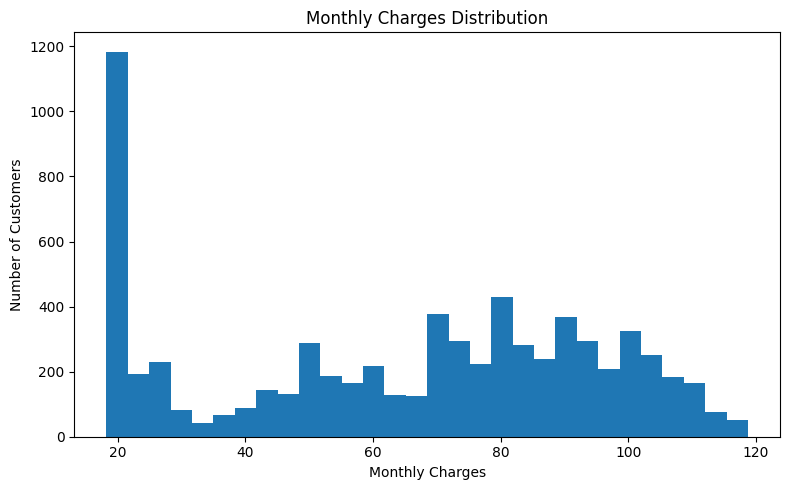

In [77]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["MonthlyCharges"],
    bins=30
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### 5.4 Numerical Features by Churn Status

Numerical characteristics are compared across churn groups to identify descriptive differences that may warrant further investigation.

These comparisons are descriptive and should not be interpreted as causal relationships.

In [78]:
# Tenure by churn
df.groupby("Churn")["tenure"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,"5,174.00",37.57,24.11,0.00,15.00,38.00,61.00,72.00
Yes,"1,869.00",17.98,19.53,1.00,2.00,10.00,29.00,72.00


In [79]:
# Monthly charges by churn
df.groupby("Churn")["MonthlyCharges"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,"5,174.00",61.27,31.09,18.25,25.10,64.43,88.40,118.75
Yes,"1,869.00",74.44,24.67,18.85,56.15,79.65,94.20,118.35


<Figure size 800x500 with 0 Axes>

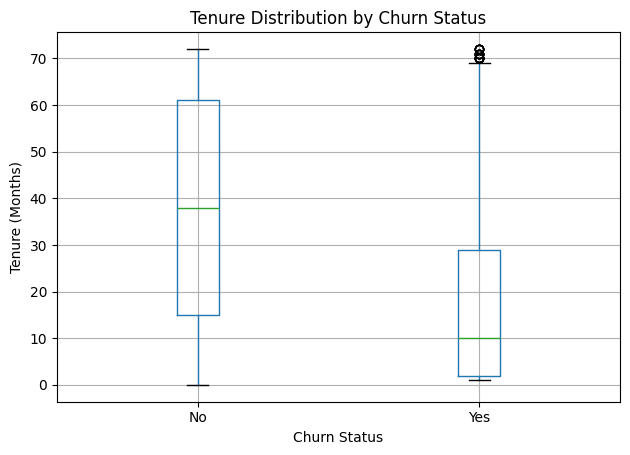

In [80]:
# Tenure-by-Churn Visualization
plt.figure(figsize=(8, 5))

df.boxplot(
    column="tenure",
    by="Churn"
)

plt.title("Tenure Distribution by Churn Status")
plt.suptitle("")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

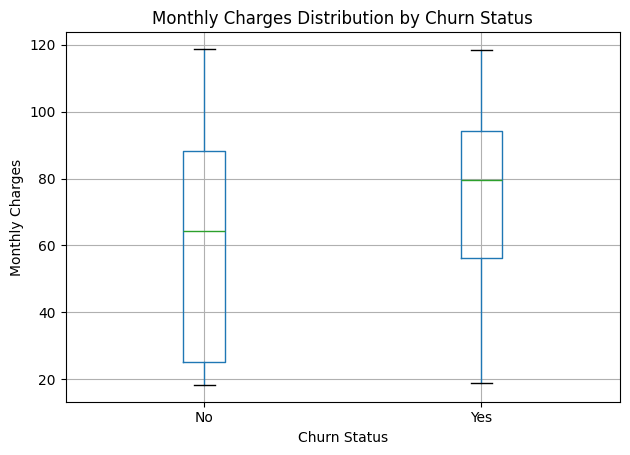

In [81]:
# Monthly Charges by Churn Visualization
plt.figure(figsize=(8, 5))

df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges Distribution by Churn Status")
plt.suptitle("")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

In [82]:
numerical_churn_summary = (
    df.groupby("Churn")[["tenure", "MonthlyCharges"]]
      .mean()
      .round(2)
)

numerical_churn_summary

,tenure,MonthlyCharges
Churn,,
No,37.57,61.27
Yes,17.98,74.44


In [83]:
numerical_churn_median = (
    df.groupby("Churn")[["tenure", "MonthlyCharges"]]
      .median()
      .round(2)
)

numerical_churn_median

,tenure,MonthlyCharges
Churn,,
No,38.00,64.43
Yes,10.00,79.65


### 5.5 Numerical Feature Findings

The numerical analysis shows meaningful descriptive differences between
customers who churned and those who remained.

#### Tenure

Churned customers have substantially shorter customer relationships than
retained customers.

- Retained customers have an average tenure of 37.57 months and a median
  tenure of 38 months.
- Churned customers have an average tenure of 17.98 months and a median
  tenure of 10 months.

The large difference in median tenure suggests that early-stage customers
represent an important population for further churn-risk investigation.

#### Monthly Charges

Churned customers also show higher monthly charges on average.

- Retained customers have average monthly charges of $61.27 and median
  monthly charges of $64.43.
- Churned customers have average monthly charges of $74.44 and median
  monthly charges of $79.65.

This difference is particularly relevant to the business objective because
customers with higher recurring charges may represent greater potential
revenue exposure when they churn.

These findings are descriptive associations rather than causal conclusions.
Further analysis of subscription characteristics and customer segments is
required to determine which factors are most strongly associated with churn.